In [4]:
from obspy import read
from scipy.signal import resample
import numpy as np
from IPython.display import Audio

def play_sac_audio(data, fs_orig, audio_rate=16000, gain=50.0, speed_up=20.0):
    """
    播放 SAC 地震信号为声音（强烈建议加速以变为可听范围）

    参数:
    - sac_file: SAC 文件路径
    - audio_rate: 最终音频采样率（建议 16000）
    - gain: 放大倍数（建议 30–100）
    - speed_up: 时间压缩倍数（将地震信号“加速”播放）
    """

    # 去直流，放大
    data = (data - np.mean(data)) * gain

    # 时间压缩：加快 speed_up 倍，即原始数据看作加快后的采样
    fs_target = fs_orig * speed_up

    # 重新采样到音频采样率
    n_samples = int(len(data) * audio_rate / fs_target)
    data_audio = resample(data, n_samples)

    # 归一化，防止爆音
    max_val = np.max(np.abs(data_audio))
    if max_val > 0:
        data_audio = data_audio / max_val

    # 返回播放器
    return Audio(data_audio, rate=audio_rate), data



In [2]:
from pathlib import Path

sacfiles = Path('/Users/zhangzhiyu/MyProjects/BaFang/vehicle_track/preprocess/save_data').glob('st_filtered*.sac')
# sacs = Path('/Volumes/SanDisk2T/BaFang/02/').glob('*.sac')
sac = Path('/Volumes/SanDisk2T/BaFang/02/20250716.020000_19030050_EHZ_1.00.sac')

agcfiles = Path('/Users/zhangzhiyu/MyProjects/BaFang/vehicle_track/preprocess/save_data').glob('agc_*.sac')


In [42]:
# 使用方法
audio, data = play_sac_audio(list(sacfiles)[0], audio_rate=16000, gain=200.0, speed_up=30.0)
audio

In [3]:
# 使用方法
audio, data = play_sac_audio(sac, audio_rate=16000, gain=200.0, speed_up=30.0)
audio

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/SanDisk2T/BaFang/02/20250716.020000_19030050_EHZ_1.00.sac'

In [47]:
# 使用方法
audio, data = play_sac_audio(list(agcfiles)[0], audio_rate=16000, gain=200.0, speed_up=30.0)
audio

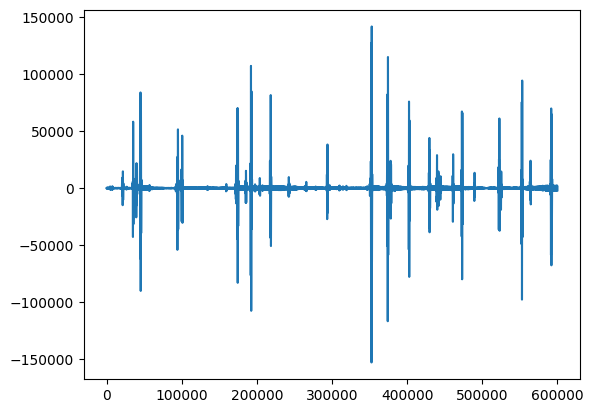

In [43]:
import matplotlib.pyplot as plt

plt.plot(data)

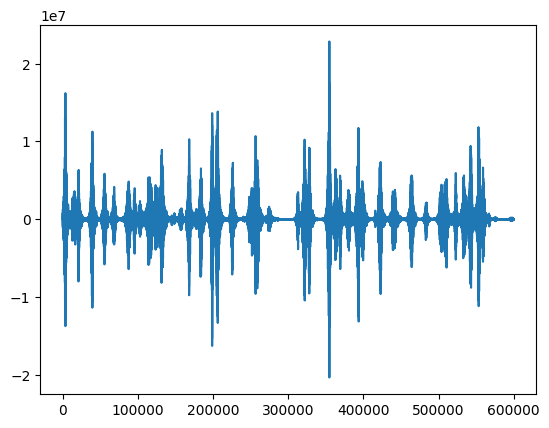

In [50]:
import matplotlib.pyplot as plt

plt.plot(data)

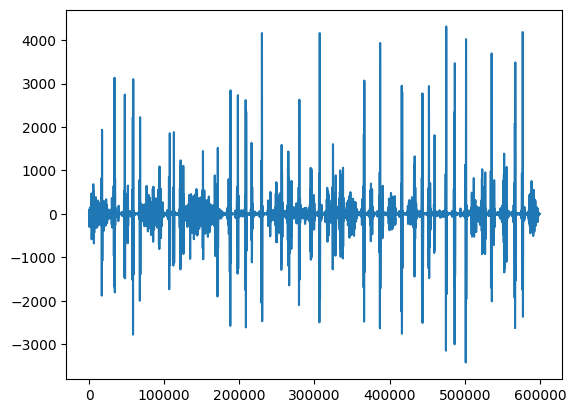

In [48]:
import matplotlib.pyplot as plt

plt.plot(data)